# Ternary Fit to Experimental Data

## Goal
In this tutorial, you will learn how to fit the soft interaction parameters ($\varepsilon_2, \varepsilon_3$) to experimental protein stability data using the **ternary crowding model**.

We will use experimental $\Delta\Delta G$ data for the AQ16 peptide in a mixture of Urea and TMAO.

## Setup
We import the required libraries.

In [1]:
import fh_crowding
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print(f"Module imported successfully: {fh_crowding.__name__}")

Module imported successfully: fh_crowding


## Load Experimental Data
We will load the `aq16_urea_tmao_ternary_format1_dG.csv` dataset from `app/sample_data/`. 
This is a "linear" format file where each row contains the concentration of Cosolute 2 (Urea), Cosolute 3 (TMAO), and the measured $\Delta\Delta G$ in **kJ/mol**.

In [2]:
# Locate the sample data path
ROOT = Path.cwd()
while not (ROOT / "app").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

sample_data_path = ROOT / "app" / "sample_data" / "aq16_urea_tmao_ternary_format1_dG.csv"

# Load the data
df = pd.read_csv(sample_data_path)

# Drop any NaNs
df = df.dropna()

display(df.head())

,conc2,conc3,dG
0,0.0001,0.00010,0.00010
1,0.0001,0.50086,-0.29763
2,0.0001,0.99967,-0.43983
3,0.0001,1.50328,-0.54424
4,0.0001,2.00414,-0.64382


## Data Preparation
We will extract the concentrations (which are in molal) and energies into numpy arrays. The energies are already in kJ/mol, which is exactly what the model expects!

In [3]:
exp_conc2 = df["conc2"].values
exp_conc3 = df["conc3"].values
exp_dG = df["dG"].values

## Define Model Parameters
We define the Protein (AQ16), Urea (Cosolute 2), and TMAO (Cosolute 3), and place them into a `CosoluteMixture`.
When fitting, we still have to provide a concentration grid so the model can solve the background thermodynamics. We must ensure `phi_max2` and `phi_max3` are large enough to cover the experimental molal ranges (up to ~6 m for Urea, ~4 m for TMAO). We will use a relatively coarse grid (`dphiC=0.01`) for faster fitting.

In [5]:
# Define Protein
protein = fh_crowding.Protein(SASA=242.6)

mixture = fh_crowding.CosoluteMixture(
    nu2=2.479, nu3=3.980, 
    chi12=0.610, chi13=-0.680, chi23=0.963, 
    chiTS12=-3.650, chiTS13=-5.708, chiTS23=-38.810
)

# Initialize the model 
model = fh_crowding.TernaryCrowdingModel(
    protein=protein,
    cosolutes=mixture,
    eps2=0.0,
    eps3=0.0,
    epsTS2=0.0,
    epsTS3=0.0,
    phi2_max=0.22,    
    phi3_max=0.23,    
    dphi2=0.01,       # Coarse grid for faster computation
    dphi3=0.01,
    T=298.15
)

## Fit $\varepsilon_2$ and $\varepsilon_3$ simultaneously
The `fit_eps` method in the ternary model optimizes both $\varepsilon_2$ and $\varepsilon_3$ at the same time to best match the 2D experimental surface.
We explicitly pass `concentration_type="molal"`.

**Note:** While we show a simultaneous fit here as a technical example, this is **not** the proper way to fit these parameters. A simultaneous fit can mix the individual contributions of $\varepsilon_2$, $\varepsilon_3$, and the synergistic term $\varepsilon_{23}$. The proper approach is a **sequential fit**, which we demonstrate in the next section.

In [7]:
# Fit eps2 and eps3
model.fit_eps(
    exp_conc2=exp_conc2, 
    exp_conc3=exp_conc3, 
    exp_ddG=exp_dG, 
    concentration_type='molal',
    fit_eps23=True
)

print(f"Fitted eps2 (Urea): {model.eps2:.4f}")
print(f"Fitted eps3 (TMAO): {model.eps3:.4f}")

# Solve the full grid to populate the model arrays before plotting
model.solve_equil()
print("-------------------------\n",model)

Optimization terminated successfully.
         Current function value: 1.239175
         Iterations: 1
         Function evaluations: 37
Fitted eps2 (Urea): -0.3300
Fitted eps3 (TMAO): -0.0046
-------------------------
 Mean-Field Model ternary:
Soft_Interaction2-> (ε₂=-0.329998409058939, εₛ₂=0.0)
Soft_Interaction3-> (ε₃=-0.0046284304716978876, εₛ₃=0.0)
Soft_Interaction3-> (ε₂₃=0.19791011215767038, εₛ₂₃=0) 
Protein-> (SASA=242.6)
Cosolutes:
Cosolute2-> (ν₂=2.479, χ₁₂=0.61, χₛ₁₂=-3.65)
Cosolute3-> (ν₃=3.98, χ₁₃=-0.68, χₛ₁₃=-5.708)
(χₛ₂₃=0.963, χₛ₂₃=-38.81)


## Proper Approach: Sequential Fit
To correctly disentangle the individual interactions from the synergy, we must fit the parameters sequentially:
1. Fit $\varepsilon_2$ on the Cosolute 2 (Urea) binary data.
2. Fit $\varepsilon_3$ on the Cosolute 3 (TMAO) binary data.
3. Finally, fit the synergistic interaction parameter $\varepsilon_{23}$ on the full ternary dataset while keeping $\varepsilon_2$ and $\varepsilon_3$ fixed.

In [8]:
# Create a fresh model for sequential fitting
model_seq = fh_crowding.TernaryCrowdingModel(
    protein=protein,
    cosolutes=mixture,
    eps2=0.0,
    eps3=0.0,
    epsTS2=0.0,
    epsTS3=0.0,
    phi2_max=0.22,    
    phi3_max=0.23,    
    dphi2=0.01,       # Coarse grid for faster computation
    dphi3=0.01,
    T=298.15
)

# 1. Fit eps2 using Urea binary data (where conc3 is negligible)
mask_urea = exp_conc3 < 0.01
model_seq.fit_eps(
    exp_conc2=exp_conc2[mask_urea], 
    exp_conc3=exp_conc3[mask_urea], 
    exp_ddG=exp_dG[mask_urea], 
    concentration_type='molal',
    fit_eps2=True,
    fit_eps3=False,
    fit_eps23=False
)
print(f"Sequentially fitted eps2 (Urea): {model_seq.eps2:.4f}")

# 2. Fit eps3 using TMAO binary data (where conc2 is negligible)
mask_tmao = exp_conc2 < 0.01
model_seq.fit_eps(
    exp_conc2=exp_conc2[mask_tmao], 
    exp_conc3=exp_conc3[mask_tmao], 
    exp_ddG=exp_dG[mask_tmao], 
    concentration_type='molal',
    fit_eps2=False,
    fit_eps3=True,
    fit_eps23=False
)
print(f"Sequentially fitted eps3 (TMAO): {model_seq.eps3:.4f}")

# 3. Fit eps23 using the full dataset
model_seq.fit_eps(
    exp_conc2=exp_conc2, 
    exp_conc3=exp_conc3, 
    exp_ddG=exp_dG, 
    concentration_type='molal',
    fit_eps2=False,
    fit_eps3=False,
    fit_eps23=True
)
print(f"Sequentially fitted eps23 (Synergy): {model_seq.eps23:.4f}")

# Solve the full grid to populate the model arrays before plotting
model_seq.solve_equil()
model.solve_equil()
print("-------------------------\n",model_seq)

Optimization terminated successfully.
         Current function value: 0.864833
         Iterations: 2
         Function evaluations: 25
Sequentially fitted eps2 (Urea): -0.3401
Optimization terminated successfully.
         Current function value: 0.053388
         Iterations: 2
         Function evaluations: 26
Sequentially fitted eps3 (TMAO): -0.0006
Optimization terminated successfully.
         Current function value: 1.365521
         Iterations: 2
         Function evaluations: 36
Sequentially fitted eps23 (Synergy): 0.3057
-------------------------
 Mean-Field Model ternary:
Soft_Interaction2-> (ε₂=-0.3401162690502317, εₛ₂=0.0)
Soft_Interaction3-> (ε₃=-0.0006254786266653224, εₛ₃=0.0)
Soft_Interaction3-> (ε₂₃=0.30572727049161436, εₛ₂₃=0) 
Protein-> (SASA=242.6)
Cosolutes:
Cosolute2-> (ν₂=2.479, χ₁₂=0.61, χₛ₁₂=-3.65)
Cosolute3-> (ν₃=3.98, χ₁₃=-0.68, χₛ₁₃=-5.708)
(χₛ₂₃=0.963, χₛ₂₃=-38.81)


To track the differences in $\varepsilon_2$, $\varepsilon_3$, and $\varepsilon_{23}$ we plot the values and the $\Delta$

/tmp/ipykernel_487529/4182689767.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


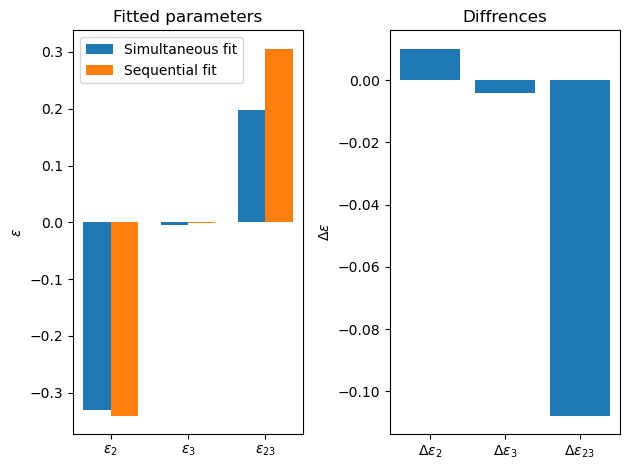

In [9]:
eps_model = {r"$\varepsilon_2$":model.eps2, 
        r"$\varepsilon_3$":model.eps3, 
        r"$\varepsilon_{23}$":model.eps23}

eps_model_seq = {r"$\varepsilon_2$":model_seq.eps2, 
        r"$\varepsilon_3$":model_seq.eps3, 
        r"$\varepsilon_{23}$":model_seq.eps23}

deps2 = model.eps2-model_seq.eps2
deps3 = model.eps3-model_seq.eps3
deps23 = model.eps23-model_seq.eps23
deps = {r"$\Delta\varepsilon_2$":deps2, 
        r"$\Delta\varepsilon_3$":deps3, 
        r"$\Delta\varepsilon_{23}$":deps23}

labels = eps_model.keys()
width=0.35
x = np.arange(len(eps_model.keys()))
fig, ax = plt.subplots(1,2)
#ax[0].bar(eps_model.keys(), eps_model.values())
#ax[0].bar(eps_mode_seq.keys(), eps_mode_seq.values())
ax[0].bar(x - width/2, eps_model.values(), width, label="Simultaneous fit")
ax[0].bar(x + width/2, eps_model_seq.values(), width, label="Sequential fit")
ax[1].bar(deps.keys(), deps.values())

ax[0].set_xticks(x)
ax[0].set_xticklabels(labels)
ax[0].set_ylabel(r"$\varepsilon$")
ax[0].set_title("Fitted parameters")
ax[0].legend()

ax[1].set_ylabel(r"$\Delta\varepsilon$")
ax[1].set_title("Diffrences")
fig.tight_layout()
fig.show()

## Visualizing the Sequential Fit
The `TernaryPlotter` can overlay the experimental data points on the 2D contour map to visually assess the quality of the fit.
Because the points are scatter points in 3D (conc2, conc3, dG), the plotter typically projects them or colors them according to the contour map.

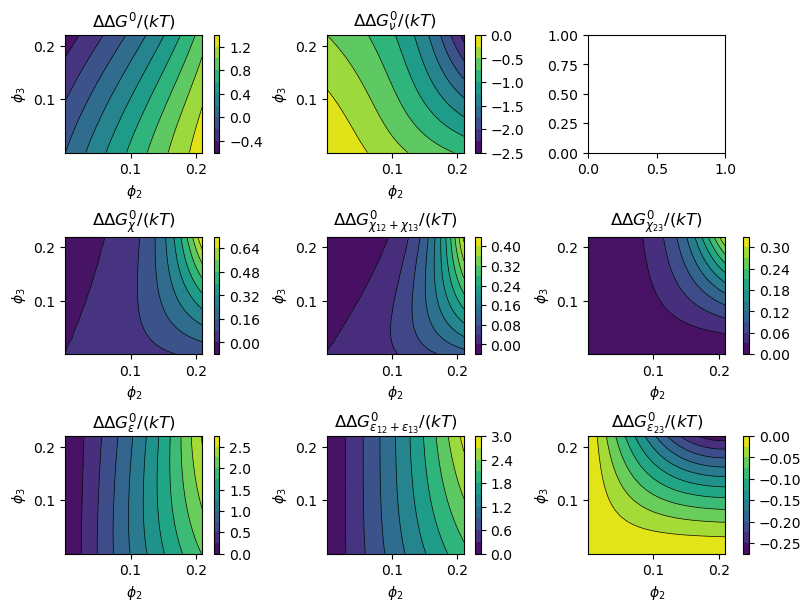

In [10]:
from fh_crowding.plotting import TernaryPlotter

plotter = TernaryPlotter(model_seq)

# The plotter will overlay the experimental scatter points if provided
fig = plotter.plot_ddG()
plt.show()

## 3D Visualization of the Total Free Energy

Using `plotly`, we can create an interactive 3D plot of the total free energy surface alongside the experimental data points and binary fit lines.

In [11]:
import plotly.graph_objects as go

def plot_interactive_3d(model, exp_conc2, exp_conc3, exp_data, title, zaxis_title):
    X = model.molal2
    Y = model.molal3
    
    if "G" in zaxis_title:
        Z = model.ddG_kJ
    elif "H" in zaxis_title:
        Z = model.ddH_kJ
    elif "S" in zaxis_title:
        Z = model.TddS_kJ
        
    fig = go.Figure()

    # Surface plot for the model
    fig.add_trace(go.Surface(
        x=X, y=Y, z=Z,
        colorscale='Viridis',
        opacity=0.7,
        name='Model Surface',
        showscale=False
    ))

    # Scatter plot for experimental data
    fig.add_trace(go.Scatter3d(
        x=exp_conc2, y=exp_conc3, z=exp_data,
        mode='markers',
        marker=dict(size=6, color='red', symbol='circle', line=dict(width=1, color='darkred')),
        name='Experimental Data'
    ))

    # Binary edges (Urea and TMAO fits)
    fig.add_trace(go.Scatter3d(
        x=X[0, :], y=Y[0, :], z=Z[0, :],
        mode='lines',
        line=dict(color='blue', width=5),
        name='TMAO Binary Fit'
    ))
    fig.add_trace(go.Scatter3d(
        x=X[:, 0], y=Y[:, 0], z=Z[:, 0],
        mode='lines',
        line=dict(color='orange', width=5),
        name='Urea Binary Fit'
    ))

    fig.update_layout(
        title=dict(
        text=title,
        x=0.5
        ),
        scene=dict(
            xaxis_title='Urea (molal)',
            yaxis_title='TMAO (molal)',
            zaxis_title=zaxis_title,
            aspectmode='manual',
            aspectratio=dict(x=1, y=1, z=0.7)
        ),
        width=600,
        height=400,
        margin=dict(l=40, r=40, b=40, t=40)
    )
    return fig

fig_dG = plot_interactive_3d(model_seq, 
                            exp_conc2, 
                            exp_conc3, 
                            exp_dG, 
                            'Ternary Model Fit: ΔΔG Surface', 
                            'ΔΔG (kJ mol⁻¹)')
fig_dG.show()

## Sequential Fit of Enthalpic ($\Delta\Delta H$) and Entropic ($T\Delta\Delta S$) Components

Once the soft interaction parameters ($\epsilon_2, \epsilon_3, \epsilon_{23}$) are determined, we can sequentially fit the entropic contributions ($\epsilon_{TS2}, \epsilon_{TS3}, \epsilon_{TS23}$) using the `fit_epsTS` method.
We will load the `_dH.csv` and `_TdS.csv` experimental files to fit both enthalpy and entropy simultaneously at each stage.

In [12]:
# Locate the sample data path for enthalpy and entropy
path_dH = ROOT / "app" / "sample_data" / "aq16_urea_tmao_ternary_format1_dH.csv"
path_TdS = ROOT / "app" / "sample_data" / "aq16_urea_tmao_ternary_format1_TdS.csv"

# Load the data
df_dH = pd.read_csv(path_dH).dropna()
df_TdS = pd.read_csv(path_TdS).dropna()

exp_conc2_TS = df_dH["conc2"].values
exp_conc3_TS = df_dH["conc3"].values
exp_ddH = df_dH["dH"].values
exp_TddS = df_TdS["TdS"].values

# Ensure we use the sequentially fitted model (model_seq) 
# 1. Fit epsTS2 using Urea binary data (where conc3 < 0.01)
mask_urea_TS = exp_conc3_TS < 0.01
model_seq.fit_epsTS(
    exp_conc2=exp_conc2_TS[mask_urea_TS], 
    exp_conc3=exp_conc3_TS[mask_urea_TS], 
    exp_ddH=exp_ddH[mask_urea_TS],
    exp_TddS=exp_TddS[mask_urea_TS],
    concentration_type='molal',
    fit_epsTS2=True,
    fit_epsTS3=False,
    fit_epsTS23=False
)
print(f"Sequentially fitted epsTS2 (Urea): {model_seq.epsTS2:.4f}")

# 2. Fit epsTS3 using TMAO binary data (where conc2 < 0.01)
mask_tmao_TS = exp_conc2_TS < 0.01
model_seq.fit_epsTS(
    exp_conc2=exp_conc2_TS[mask_tmao_TS], 
    exp_conc3=exp_conc3_TS[mask_tmao_TS], 
    exp_ddH=exp_ddH[mask_tmao_TS],
    exp_TddS=exp_TddS[mask_tmao_TS],
    concentration_type='molal',
    fit_epsTS2=False,
    fit_epsTS3=True,
    fit_epsTS23=False
)
print(f"Sequentially fitted epsTS3 (TMAO): {model_seq.epsTS3:.4f}")

# 3. Fit epsTS23 using the full dataset
model_seq.fit_epsTS(
    exp_conc2=exp_conc2_TS, 
    exp_conc3=exp_conc3_TS, 
    exp_ddH=exp_ddH,
    exp_TddS=exp_TddS,
    concentration_type='molal',
    fit_epsTS2=False,
    fit_epsTS3=False,
    fit_epsTS23=True
)
print(f"Sequentially fitted epsTS23 (Synergy): {model_seq.epsTS23:.4f}")

# Solve the full grid to populate the model arrays before plotting
model_seq.solve_equil()

print('-----------------------------\n',model_seq)

Sequentially fitted epsTS2 (Urea): -0.7825
Sequentially fitted epsTS3 (TMAO): 0.5959
Sequentially fitted epsTS23 (Synergy): -1.9780
-----------------------------
 Mean-Field Model ternary:
Soft_Interaction2-> (ε₂=-0.3401162690502317, εₛ₂=-0.7824791790585516)
Soft_Interaction3-> (ε₃=-0.0006254786266653224, εₛ₃=0.595897593271056)
Soft_Interaction3-> (ε₂₃=0.30572727049161436, εₛ₂₃=-1.9780158515707726) 
Protein-> (SASA=242.6)
Cosolutes:
Cosolute2-> (ν₂=2.479, χ₁₂=0.61, χₛ₁₂=-3.65)
Cosolute3-> (ν₃=3.98, χ₁₃=-0.68, χₛ₁₃=-5.708)
(χₛ₂₃=0.963, χₛ₂₃=-38.81)


### 3D Visualization of $\Delta\Delta H$ and $T\Delta\Delta S$

In [13]:
fig_dH = plot_interactive_3d(model_seq, 
                        exp_conc2_TS, 
                        exp_conc3_TS, 
                        exp_ddH, 
                        'Ternary Model Fit: ΔΔH Surface', 
                        'ΔΔ H (kJ/mol)')
fig_dH.show()

fig_TdS = plot_interactive_3d(model_seq, 
                        exp_conc2_TS, 
                        exp_conc3_TS, 
                        exp_TddS, 
                        'Ternary Model Fit: TΔΔ S Surface', 
                        'TΔΔ S (kJ/mol)')
fig_TdS.show()